This notebook investigates whether the GDP per capita of countries have any association with ICE removals over time. We have limitations on the data accessible to us thus, we will be making an assumption that a persons departure country (contained in the ice dataset) is their country of origin.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
gdp = pd.read_csv('API_NY.GDP.PCAP.CD_DS2_en_csv_v2_245.csv', skiprows=4)

print(gdp.head())

                  Country Name Country Code                Indicator Name  \
0                        Aruba          ABW  GDP per capita (current US$)   
1  Africa Eastern and Southern          AFE  GDP per capita (current US$)   
2                  Afghanistan          AFG  GDP per capita (current US$)   
3   Africa Western and Central          AFW  GDP per capita (current US$)   
4                       Angola          AGO  GDP per capita (current US$)   

   Indicator Code        1960        1961        1962        1963        1964  \
0  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   
1  NY.GDP.PCAP.CD  186.089204  186.909053  197.367547  225.400079  208.962717   
2  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   
3  NY.GDP.PCAP.CD  121.936832  127.451040  133.823783  139.004980  148.545883   
4  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   

         1965  ...          2017          2018    

In [3]:
#ensures we format data by country
gdp_long = gdp.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[str(y) for y in range(2010, 2024)],
    var_name='year',
    value_name='gdp_per_capita'
)

gdp_long['year'] = gdp_long['year'].astype(int)
gdp_long = gdp_long.dropna(subset=['gdp_per_capita'])
gdp_long.columns = ['country_name', 'country_code', 'year', 'gdp_per_capita']

print(gdp_long.head())

                  country_name country_code  year  gdp_per_capita
0                        Aruba          ABW  2010    24093.140151
1  Africa Eastern and Southern          AFE  2010     1628.905248
2                  Afghanistan          AFG  2010      560.621505
3   Africa Western and Central          AFW  2010     1662.633658
4                       Angola          AGO  2010     4101.637156


In [4]:
removals = pd.read_csv('removals_10yr.csv', usecols=['Departure Country', 'Departure Date'])

removals['year'] = pd.to_datetime(removals['Departure Date'], errors='coerce').dt.year

removals_by_country = removals.groupby(['Departure Country', 'year']).size().reset_index(name='removal_count')

print(removals_by_country.head())

  Departure Country  year  removal_count
0       AFGHANISTAN  2011              5
1       AFGHANISTAN  2012             18
2       AFGHANISTAN  2013             10
3       AFGHANISTAN  2014             20
4       AFGHANISTAN  2015              4


In [5]:
#join both the gdp and removals dataset
removals_by_country['country_name'] = removals_by_country['Departure Country'].str.title()

merged_gdp = pd.merge(
    removals_by_country,
    gdp_long,
    on=['country_name', 'year'],
    how='inner'
)

print(merged_gdp.shape)
print(merged_gdp.head())

(1611, 6)
  Departure Country  year  removal_count country_name country_code  \
0       AFGHANISTAN  2011              5  Afghanistan          AFG   
1       AFGHANISTAN  2012             18  Afghanistan          AFG   
2       AFGHANISTAN  2013             10  Afghanistan          AFG   
3       AFGHANISTAN  2014             20  Afghanistan          AFG   
4       AFGHANISTAN  2015              4  Afghanistan          AFG   

   gdp_per_capita  
0      606.694676  
1      651.417134  
2      637.087099  
3      625.054942  
4      565.569730  


In [6]:
top10 = merged_gdp.groupby('country_name').agg(
    total_removals=('removal_count', 'sum'),
    avg_gdp=('gdp_per_capita', 'mean')
).nlargest(10, 'total_removals').reset_index()

print(top10)

         country_name  total_removals       avg_gdp
0              Mexico         1534414  10217.719766
1           Guatemala          383620   4011.157443
2            Honduras          268805   2314.726675
3         El Salvador          178090   3902.914855
4  Dominican Republic           21070   7052.343931
5             Ecuador           16985   5951.266427
6              Brazil           16128  10171.131672
7           Nicaragua           12529   1974.326975
8            Colombia           11751   6865.055943
9               Haiti           11574   1426.948499


Before looking at the trends over time, we wanted to see which countries had the most removals and their corresponding average gdp per capita. Mexico is leading with upwards of a million removals.

In [7]:
#calculate average gdp of countries per year
def weighted_avg_gdp(group):
    return (group['gdp_per_capita'] * group['removal_count']).sum() / group['removal_count'].sum()

yearly = merged_gdp.groupby('year').apply(
    lambda g: pd.Series({
        'total_removals': g['removal_count'].sum(),
        'weighted_avg_gdp': weighted_avg_gdp(g)
    })
).reset_index()

print(yearly.head())

   year  total_removals  weighted_avg_gdp
0  2011         90174.0       9234.327304
1  2012        403372.0       8989.030565
2  2013        349025.0       8699.903982
3  2014        298233.0       8218.860262
4  2015        231452.0       8068.745843


/tmp/ipykernel_1314/671721480.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly = merged_gdp.groupby('year').apply(


We computed the weighted average GDP per capita of all countries for each year. This means that countries with more removals pull the average heavily in order to reflect who is actually being removed rather than treating all countries equally

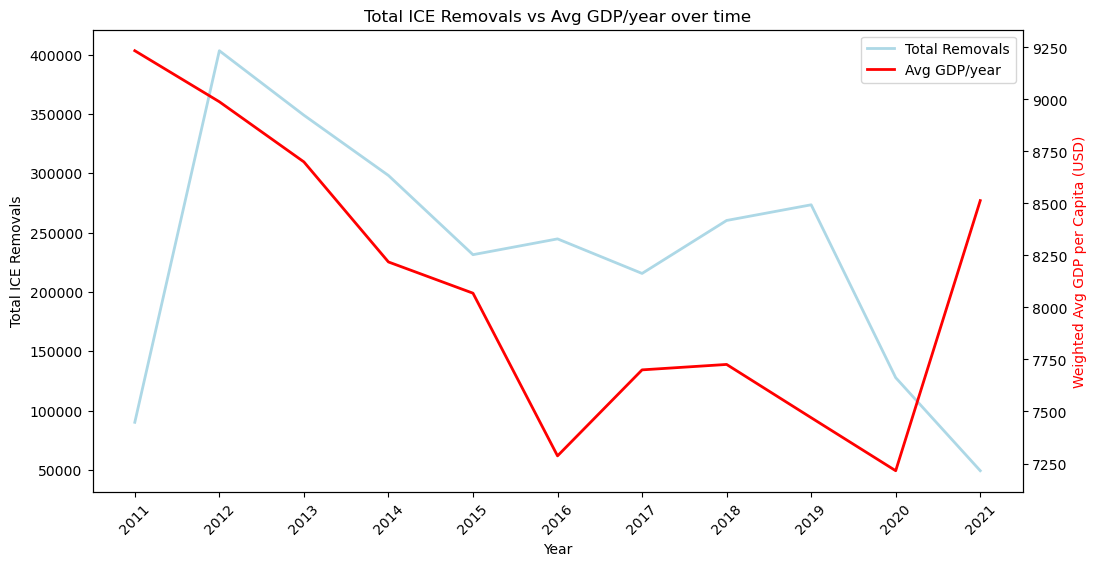

In [8]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.plot(yearly['year'], yearly['total_removals'], color='lightblue', linewidth=2, label='Total Removals')
ax2.plot(yearly['year'], yearly['weighted_avg_gdp'], color='red', linewidth=2, label='Avg GDP/year')

ax1.set_xlabel('Year')
ax1.set_ylabel('Total ICE Removals')
ax2.set_ylabel('Weighted Avg GDP per Capita (USD)', color='red')

ax1.set_xticks(yearly['year'])
ax1.tick_params(axis='x', rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Total ICE Removals vs Avg GDP/year over time')
plt.show()

The weighted average GDP and the volume of removals shows no significant trends over time and there does not seem to be a strong relationship between these two features.

Given that a majority of the removals is coming from Mexico, it is possible that it is being outsized. We will exclude Mexico in the next section to see what happens to the relationship of these two variables.

In [9]:
#we will now look at the data without Mexico's contribution to the numbers
removals2 = merged_gdp[merged_gdp['country_name'] != 'Mexico']

yearly2 = removals2.groupby('year').apply(
    lambda g: pd.Series({
        'total_removals': g['removal_count'].sum(),
        'weighted_avg_gdp': weighted_avg_gdp(g)
    }),
).reset_index()

print(yearly2.head())

   year  total_removals  weighted_avg_gdp
0  2011         24830.0       5470.620542
1  2012        117139.0       4700.378746
2  2013        124961.0       4186.928093
3  2014        131454.0       4193.807945
4  2015         83809.0       4629.116570


/tmp/ipykernel_1314/2430333693.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly2 = removals2.groupby('year').apply(


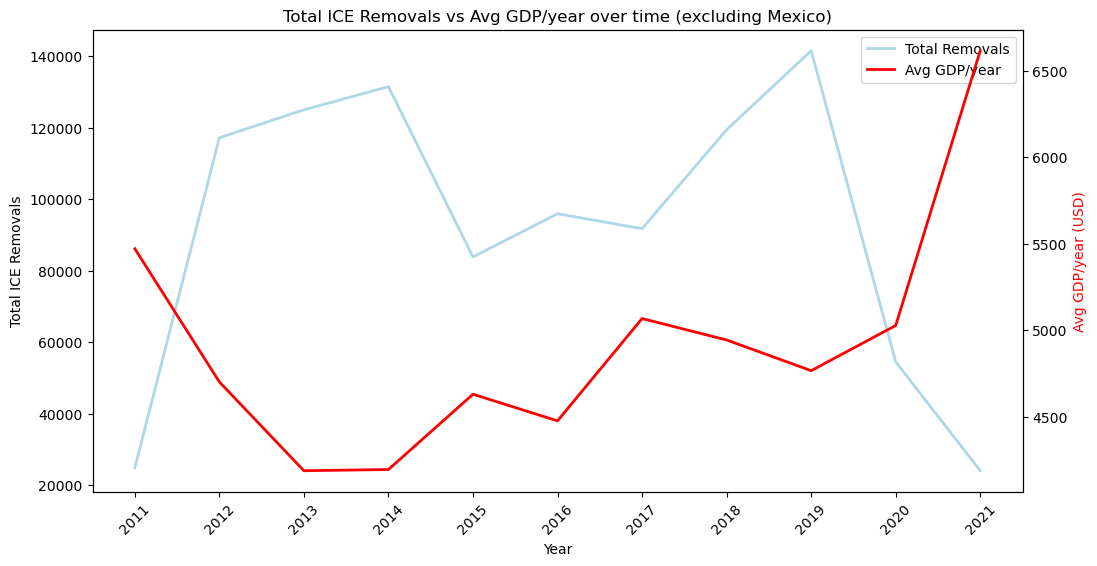

In [10]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.plot(yearly2['year'], yearly2['total_removals'], color='lightblue', linewidth=2, label='Total Removals')
ax2.plot(yearly2['year'], yearly2['weighted_avg_gdp'], color='red', linewidth=2, label='Avg GDP/year')

ax1.set_xlabel('Year')
ax1.set_ylabel('Total ICE Removals')
ax2.set_ylabel('Avg GDP/year (USD)', color='red')

ax1.set_xticks(yearly2['year'])
ax1.tick_params(axis='x', rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Total ICE Removals vs Avg GDP/year over time (excluding Mexico)')
plt.show()

Now we can see that the total removals and average GDP moves in opposite directions when we remove Mexico from the dataset. GDP tends to be low when removals are high (2013-2014) while GDP is highest when removals are low (2021). This could potentially suggest that there is a relationship between removals and the average GDP of countries.

In [11]:
corr_with_mexico = yearly['total_removals'].corr(yearly['weighted_avg_gdp'])
corr_excluding_mexico = yearly2['total_removals'].corr(yearly2['weighted_avg_gdp'])

print(f"Correlation (with Mexico): {corr_with_mexico:.4f}")
print(f"Correlation (excluding Mexico): {corr_excluding_mexico:.4f}")

Correlation (with Mexico): 0.0617
Correlation (excluding Mexico): -0.7855


When Mexico is included, we see a weak positive correlation (0.06) between total removals and the weighted average GDP likely due to Mexico's huge influence rather than a true relationship. When Mexico is excluded, the correlation becomes negative and stronger (-0.88) suggesting that the people being removed tend to come from countries with lower GDP. 

It is important to note that this does not necessarily prove causation. Removal volumnes can be heavily influenced by other such policies and factors. 

Also worth noting is that there is a limitation with our data: the ICE removal data caputres people being removed from the US not people choosing to immigrate to the US. As a result we cannot directly conclude whether country GDP is a driver of immigration-our findings speak on enforcement patters, not immigration behavior.